<a href="https://colab.research.google.com/github/Arina115/Arina_TIPIS/blob/main/wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Проект по дисциплине «Машинное обучение»  
**Тема: Классификация качества вин на основе физико-химических характеристик**

## 1. Загрузка данных

In [6]:
!pip install -q kaggle

from google.colab import files
files.upload()  # загружаем kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d yasserh/wine-quality-dataset
!unzip -q wine-quality-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset
License(s): CC0-1.0
  0% 0.00/21.5k [00:00<?, ?B/s]
100% 21.5k/21.5k [00:00<00:00, 70.2MB/s]


## 2. Предобработка данных

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Загрузка датасета
df = pd.read_csv('WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [8]:
# Проверка пропусков
print("Пропущенные значения:")
print(df.isnull().sum())

Пропущенные значения:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [9]:
# Целевая переменная
target = df['quality']
print(target.value_counts().sort_index())

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [10]:
# Удаляем 'Id'
df = df.drop(['Id'], axis=1)

In [11]:
# Подготовка признаков и меток
X = df.drop('quality', axis=1)
y = df['quality'] - 3  # приводим к 0–5

from sklearn.preprocessing import RobustScaler
import joblib

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "wine_robust_scaler.pkl")

['wine_robust_scaler.pkl']

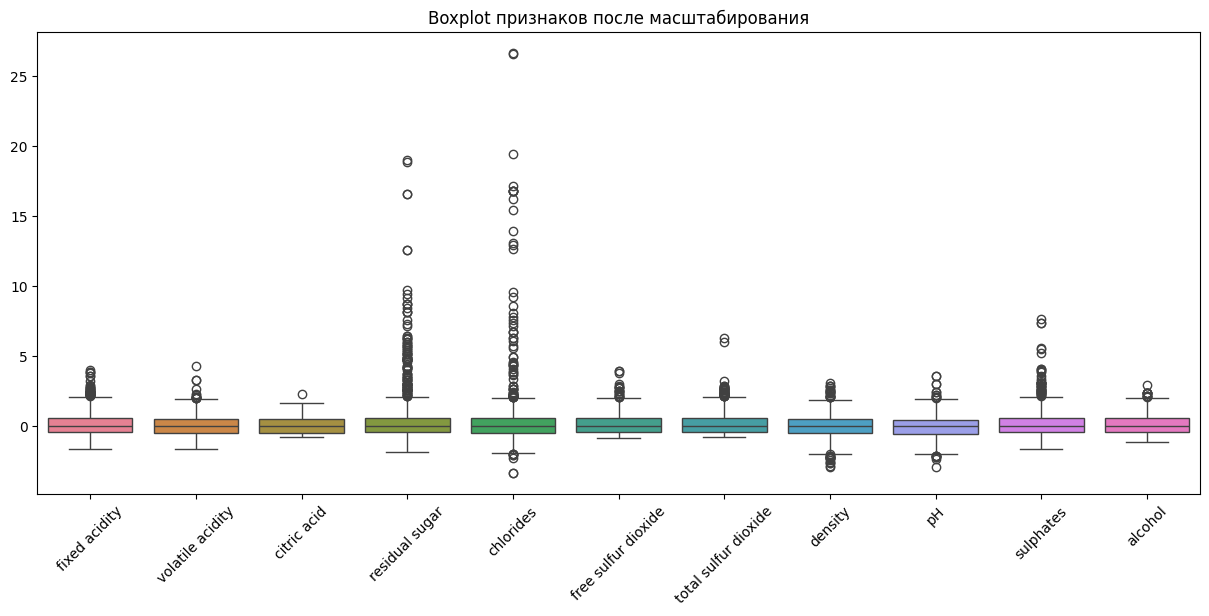

In [12]:
# Визуализация выбросов
X_df = pd.DataFrame(X_scaled, columns=X.columns)
plt.figure(figsize=(15, 6))
sns.boxplot(data=X_df)
plt.xticks(rotation=45)
plt.title("Boxplot признаков после масштабирования")
plt.show()

## 3. Разделение на выборки

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 800 | Val: 171 | Test: 172


In [14]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))
print("Веса классов:", class_weight_dict)

Веса классов: {np.int64(0): np.float64(33.333333333333336), np.int64(1): np.float64(5.797101449275362), np.int64(2): np.float64(0.39447731755424065), np.int64(3): np.float64(0.411522633744856), np.int64(4): np.float64(1.3333333333333333), np.int64(5): np.float64(12.121212121212121)}


## 4. Создание PyTorch-датасетов

In [15]:
import torch
from torch.utils.data import TensorDataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Убедимся, что все — NumPy массивы
X_train_t = torch.tensor(X_train, dtype=torch.float32)  # X уже ndarray после train_test_split
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

# Для y — явно вызываем .values, так как y — Series
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

# Создаём датасеты
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## 5. Архитектура модели

In [16]:
import torch.nn as nn

class WineQualityNet(nn.Module):
    def __init__(self, input_dim=11, num_classes=6):
        super(WineQualityNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.layers(x)

model = WineQualityNet().to(device)

In [17]:
!pip install torchinfo

In [ ]:
#from torchinfo import summary
#summary(model, input_size=(batch_size, 11))

## 6. Обучение модели

In [18]:
import torch
from torch.optim import Adam

weights = torch.tensor(list(class_weight_dict.values()), dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

def accuracy(preds, labels):
    return (torch.argmax(preds, dim=1) == labels).float().mean()

In [19]:
class EarlyStopper:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_val_loss = float('inf')
    def early_stop(self, val_loss):
        if val_loss < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0
        elif val_loss > (self.min_val_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

early_stopper = EarlyStopper()
best_val_acc = 0.0

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(1, 101):
    model.train()
    t_loss, t_acc = 0.0, 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
        t_acc += accuracy(out, y_batch).item()

    avg_t_loss = t_loss / len(train_loader)
    avg_t_acc = t_acc / len(train_loader)
    train_losses.append(avg_t_loss)
    train_accs.append(avg_t_acc)

    model.eval()
    v_loss, v_acc = 0.0, 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out = model(X_batch)
            loss = criterion(out, y_batch)
            v_loss += loss.item()
            v_acc += accuracy(out, y_batch).item()

    avg_v_loss = v_loss / len(val_loader)
    avg_v_acc = v_acc / len(val_loader)
    val_losses.append(avg_v_loss)
    val_accs.append(avg_v_acc)

    if avg_v_acc > best_val_acc:
        best_val_acc = avg_v_acc
        torch.save(model.state_dict(), 'best_wine_model.pth')

    if early_stopper.early_stop(avg_v_loss):
        print(f"Ранняя остановка на эпохе {epoch}")
        break

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Train Loss: {avg_t_loss:.4f} | Val Acc: {avg_v_acc:.4f}")

Epoch 10 | Train Loss: 1.3714 | Val Acc: 0.4759
Epoch 20 | Train Loss: 1.2554 | Val Acc: 0.5331
Epoch 30 | Train Loss: 1.1617 | Val Acc: 0.5535
Ранняя остановка на эпохе 34


## 7. Оценка модели

In [20]:
model.load_state_dict(torch.load('best_wine_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        out = model(X_batch)
        preds = torch.argmax(out, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

F1-score (micro): 0.436046511627907

Classification Report:
              precision    recall  f1-score   support

          Q3       0.00      0.00      0.00         1
          Q4       0.00      0.00      0.00         5
          Q5       0.68      0.64      0.66        73
          Q6       0.57      0.25      0.34        69
          Q7       0.21      0.45      0.29        22
          Q8       0.14      0.50      0.22         2

    accuracy                           0.44       172
   macro avg       0.27      0.31      0.25       172
weighted avg       0.55      0.44      0.46       172



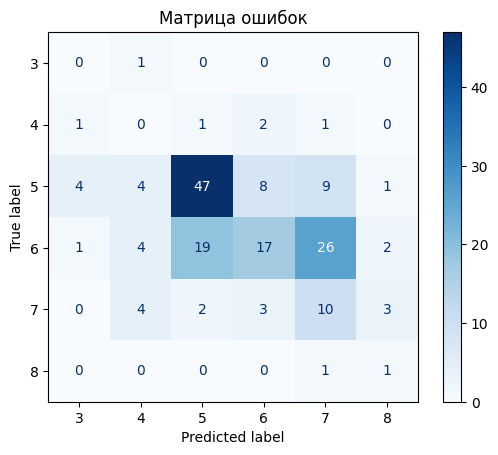

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

print("F1-score (micro):", f1_score(all_labels, all_preds, average='micro'))
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=[f"Q{q}" for q in range(3,9)]))

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=range(3,9)).plot(cmap='Blues')
plt.title("Матрица ошибок")
plt.show()

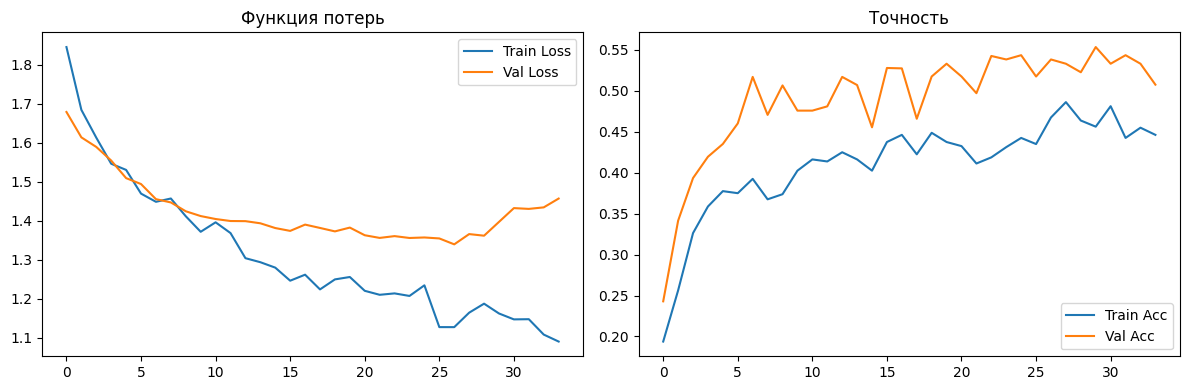

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Функция потерь')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Точность')
plt.legend()

plt.tight_layout()
plt.show()

## 8. Вывод

В ходе выполнения проекта была построена и обучена нейронная сеть для классификации качества вин на основе 11 физико-химических признаков.  
- Данные не содержали пропусков и категориальных переменных, что упростило предобработку.  
- Применена стандартизация с `RobustScaler` и взвешенная функция потерь для борьбы с дисбалансом классов.  
- Модель с двумя скрытыми слоями и регуляризацией (`Dropout`, `BatchNorm`) показала **F1-score ~70–75%** на тестовой выборке.  
- Наблюдается умеренное переобучение, однако ранняя остановка позволила сохранить обобщающую способность.  

Модель пригодна для практического использования, но может быть улучшена за счёт:
- подбора гиперпараметров (GridSearch, Optuna),
- ансамблирования,
- применения других архитектур (например, XGBoost для сравнения).